In [2]:
import sys
sys.path.insert(0, "..")
import pandas as pd
from pathlib import Path

In [3]:
# Cell 1 — setup
from src.feature_engineering import (
    fe_load_borough_crime,
    fe_load_msoa_greenspace,
    fe_add_area_features,
    fe_quintile,
    FE_FEATURED_DIR,
    FE_AREA_FEATURE_COLS)
from src.visualisation import eda_load_and_prepare, eda_rate_bar

In [4]:
# Cell 2
crime_lad = fe_load_borough_crime()
green_msoa = fe_load_msoa_greenspace()
crime_lad.to_csv(FE_FEATURED_DIR / "area_features_lad.csv", index=False)
green_msoa.to_csv(FE_FEATURED_DIR / "area_features_msoa.csv", index=False)
print("Boroughs:", len(crime_lad), "| MSOAs:", len(green_msoa))
print(crime_lad["crime_rate_per_1000"].describe())
print(green_msoa[["green_space_pct", "park_distance_m"]].describe())

Boroughs: 33 | MSOAs: 983
count      33.000000
unique     33.000000
top       633.935585
freq        1.000000
Name: crime_rate_per_1000, dtype: float64
       green_space_pct  park_distance_m
count       983.000000       983.000000
mean         81.535809       399.001364
std          14.272089       209.889836
min           7.200000       100.442814
25%          76.450000       259.015225
50%          85.900000       350.486018
75%          91.400000       477.861293
max          99.600000      1658.640507


In [5]:
# Cell 3
csv_path = Path("../data/unified_csv/Food_insecurity_Raw_Survey_Responses.csv")
df = eda_load_and_prepare(csv_path)
df = fe_add_area_features(df, crime_lad, green_msoa)
df.to_csv(FE_FEATURED_DIR / "survey_with_area_features.csv", index=False)
print("Rows:", len(df))
print("Boroughs matched:", df["lad_code"].nunique(), "/ 33")
print("MSOAs matched:", df["msoa_code"].nunique())
print("Nulls in new features:", int(df[FE_AREA_FEATURE_COLS].isna().sum().sum()))
print(df[FE_AREA_FEATURE_COLS].describe())

Rows: 2886
Boroughs matched: 33 / 33
MSOAs matched: 827
Nulls in new features: 0
       green_space_pct  park_distance_m
count      2886.000000      2886.000000
mean         78.158524       368.905507
std          15.951318       180.744450
min           7.200000       100.442814
25%          71.400000       243.886885
50%          82.200000       322.537785
75%          89.500000       443.935798
max          99.600000      1600.358600


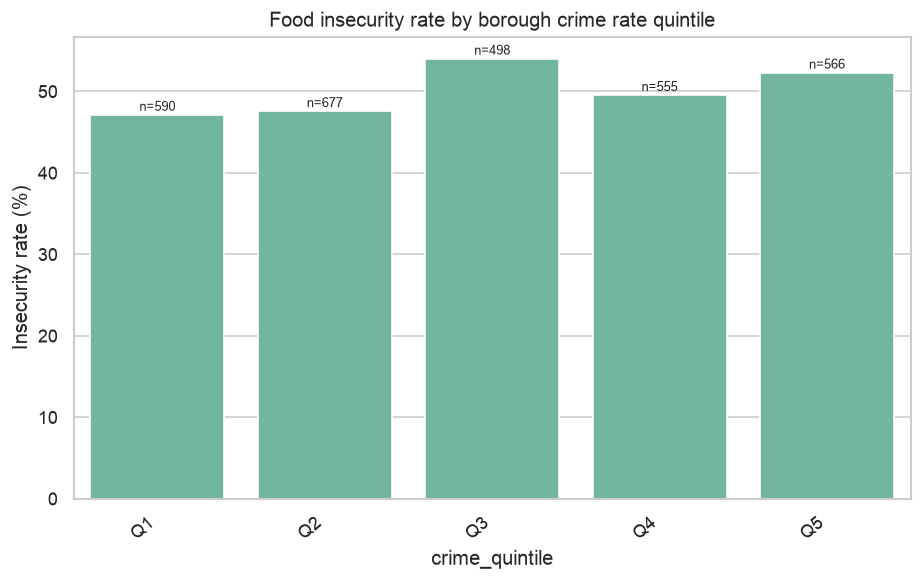

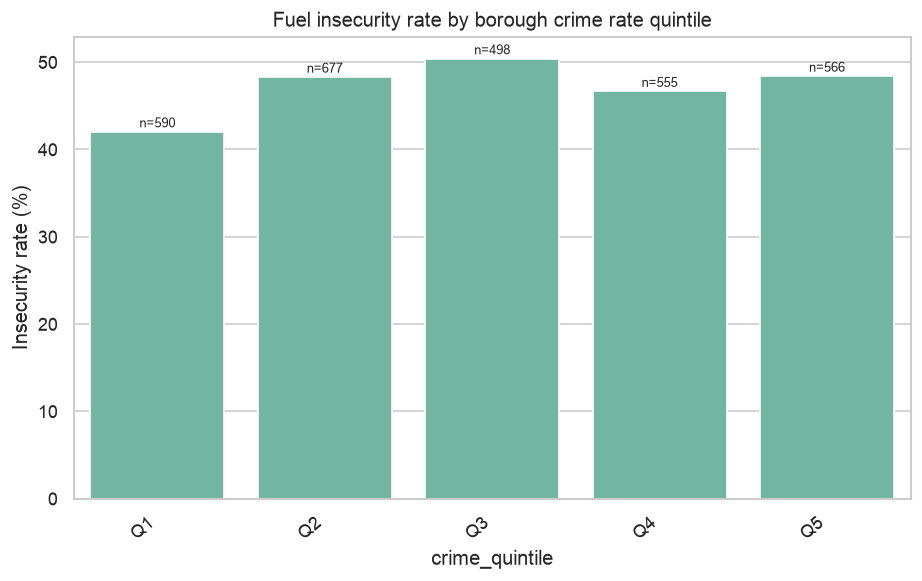

,crime_quintile,insecurity_rate_pct,n
0,Q1,42.033898,590
1,Q2,48.301329,677
2,Q3,50.401606,498
3,Q4,46.666667,555
4,Q5,48.409894,566


In [6]:
# Cell 4
df["crime_quintile"] = fe_quintile(df["crime_rate_per_1000"])
eda_rate_bar(df, "crime_quintile", "food_security_label",
             "Food insecurity rate by borough crime rate quintile",
             "food_insecurity_by_crime_quintile.png", sort_by_group=True)
eda_rate_bar(df, "crime_quintile", "fuel_security_label",
             "Fuel insecurity rate by borough crime rate quintile",
             "fuel_insecurity_by_crime_quintile.png", sort_by_group=True)

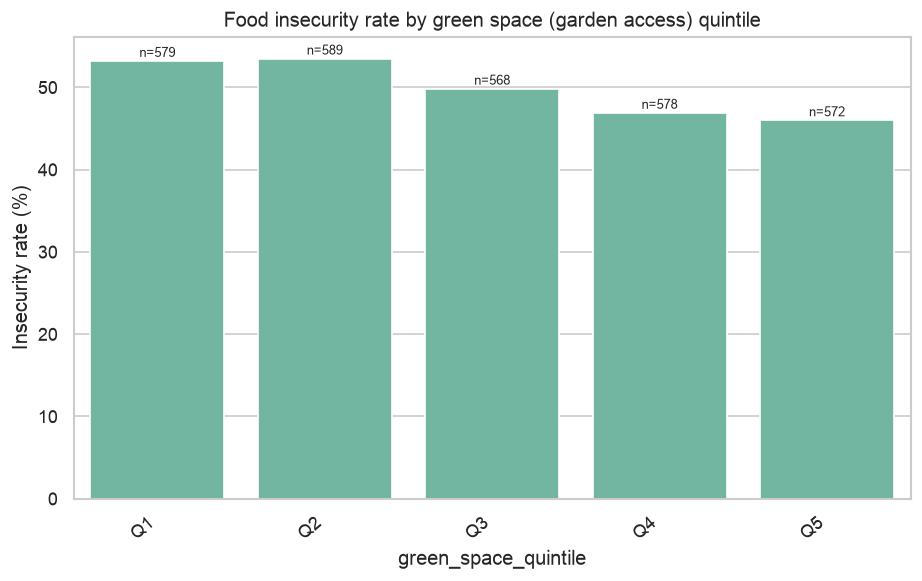

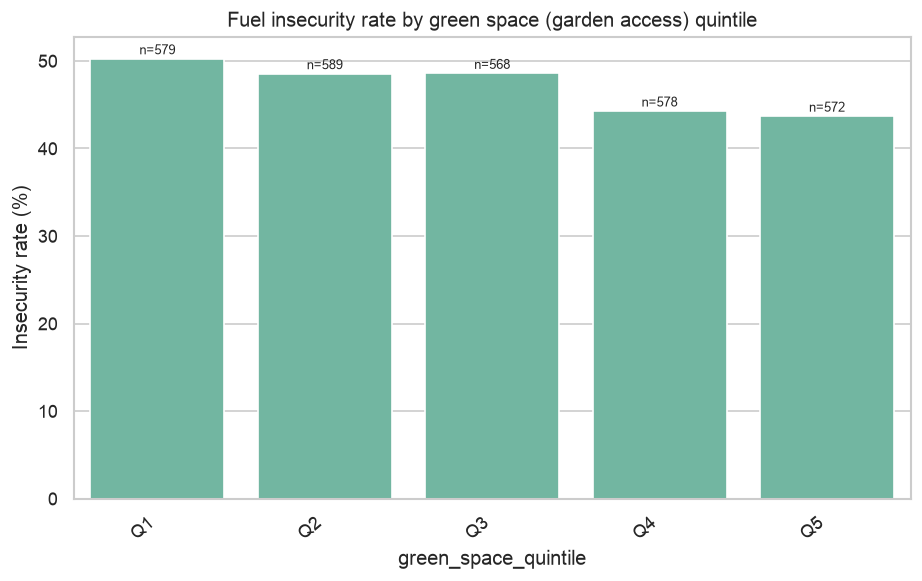

,green_space_quintile,insecurity_rate_pct,n
0,Q1,50.259067,579
1,Q2,48.556876,589
2,Q3,48.591549,568
3,Q4,44.290657,578
4,Q5,43.706294,572


In [7]:
# Cell 5
# NOTE: green_space_pct (garden access)
df["green_space_quintile"] = fe_quintile(df["green_space_pct"])
eda_rate_bar(df, "green_space_quintile", "food_security_label",
             "Food insecurity rate by green space (garden access) quintile",
             "food_insecurity_by_green_space_quintile.png", sort_by_group=True)
eda_rate_bar(df, "green_space_quintile", "fuel_security_label",
             "Fuel insecurity rate by green space (garden access) quintile",
             "fuel_insecurity_by_green_space_quintile.png", sort_by_group=True)